In [1]:
import numpy as np
from matplotlib import pyplot as plt 
import time 
from tqdm import tqdm

import jax
import jax.numpy as jnp
    
from dataclasses import dataclass
#jax.config.update("jax_disable_jit", True)


In [2]:
import nambu_class as nmb
import Eilenberger_methods as eil
import system_state as sys_state
import run_computation as comp
import custom_optimizer as copt

In [10]:
ntheta = 20
cutoff = 30 * eil.EilenbergerEvolution.get_bcs_ratio()
nw = 1000

# Define the fine grid
fine_nw = 200
fine_cutoff = 1.0* eil.EilenbergerEvolution.get_bcs_ratio()

fine_nw = nw
fine_cutoff = cutoff

grid_parameters = {'omega_sampling': nw, 'theta_sampling': ntheta, 'cutoff': cutoff}
system_parameters = {'critical_temperature': 1.0, 'gap_symmetry' : 's', 'average_indices': (2,3)}
sigma_scatterings = {'Elastic': 10.0, 'Dynes': 5.0} # {'Dynes': 0.0, 'Elastic': 0.0}
sigma_scatterings = None

my_eil = eil.EilenbergerEvolution(grid_parameters, system_parameters, sigma_scatterings = sigma_scatterings)
print(my_eil.dh_grid)
temperatures = jnp.linspace(0.1,1.2,10)
print(temperatures)

(1, 1)
[0.1        0.22222222 0.34444445 0.4666667  0.58888894 0.7111111
 0.8333334  0.9555556  1.0777779  1.2       ]


In [11]:
gap_list = []
#for temp in tqdm(temperatures):
gaps = comp.calculate_equilibrium(temp_list = temperatures, grid_parameters = grid_parameters, system_parameters = system_parameters, Q_list = [0], sigma_scatterings = sigma_scatterings)  
gap_list +=[gaps]
    


(6,)


In [12]:
print(gaps)

[1.6548116e+00-0.j 1.6506573e+00-0.j 1.6299322e+00-0.j 1.5652792e+00-0.j
 1.4368534e+00-0.j 1.2156535e+00-0.j 8.2000583e-01-0.j 8.8174909e-02-0.j
 3.6682576e-04-0.j 5.9891208e-03-0.j]


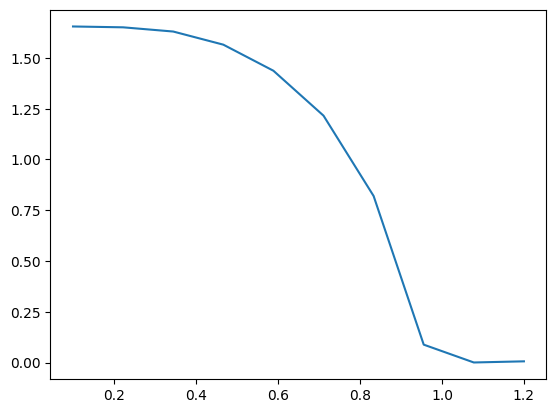

In [13]:
plt.plot(temperatures,jnp.abs(gaps))

In [7]:
l = jnp.array([0,1])
a = jnp.array([[1,2,3],[4,5,6],[7,8,9]])
print(a[l])

[[1 2 3]
 [4 5 6]]


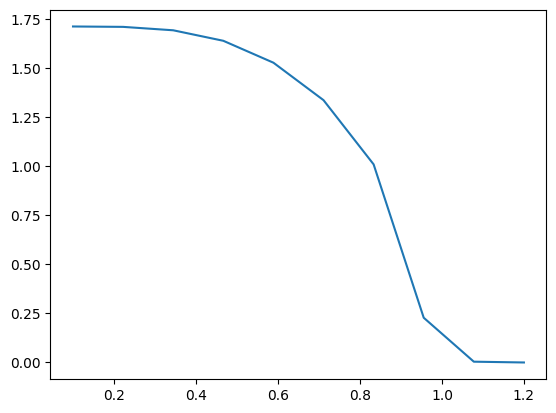

In [8]:
plt.plot(temperatures,jnp.abs(jnp.array(gaps[:])))